<a href="https://colab.research.google.com/github/dawnhsu0415/data-analytics-portfolio/blob/main/Australian_Energy_Business_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Australian Energy Business Report**



Because of the increasing importance of sustainable development issues, this business report will provide an in-depth analysis of the Australian energy industry. Utilizing the energy data of various states over the years, including oil, natural gas and renewable energy, it focuses on the analysis and visualization of energy consumption, providing policymakers and investors with reliable data analysis to make informed decisions on energy selection and use. decision making. This analysis will use SQLite3, Pandas, Matplotlib and other libraries for analysis and visualization, focusing on completing the programming practice.

The process of problem solving we will use can be broken down into 6 key steps:

1. State the problem clearly
2. Describe the input and output information
3. Work the problem by hand
4. Develop an algorithm (and convert to python)
5. Convert algorithm/pseudocode into phyton code
6. Test solution with a variety of data
7. data visualization


# 1. Problem Statement

The significant impact of the energy industry on Australia's sustainable development is critical to understand the value of energy production in each state. Population size and energy consumption are important factors in determining energy production, but the relationship of these variables among states and their impact on energy production remains unknown. Analyzing the energy production value among Australian states and exploring the relationship between population, energy consumption, and output is significant in formulating more effective energy policies and promoting economic development.

This report will focus on the analysis and visualization of the following points:

1. Compute and visualize the total energy consumption for each state.
2. Compute and visualize the total energy consumption by fuel type.
3. Analyse the per capita energy consumption for each state for each year and create a corresponding visualization.
4. Analyse and compare the growth rate of the GSP (Gross State Product) and the consumption of renewable energy for each state.

# 2. Input/Output Description

The second step, we need to collect twelve months of data on electricity, gas and water usage and then enter the data. The data output by the program will provide different graphs, such as Monthly consumption trends, Comparison of energy types and Annual total consumption.
```
            +-----------+
            |           |
 INPUT ---> | Algorithm | ---> OUTPUT
            |           |
            +-----------+
```


Another way to look at this is the problem is divided into three speerate sections:
* Input -  Australian Energy dataset as SQLite database
* Output -
1. Compute and visualize the total energy consumption for each state.
2. Compute and visualize the total energy consumption by fuel type.
3. Analyse and visualise the total energy consumption for each state, broken down by fuel type.
4. Analyse and compare the growth rate of the GSP and the consumption of renewable energy for each state.
* Processing - a list of actions needed to produce the outputs

At this step we only know the Input and outputs, but these parts can be represented as a table:

| Input         | Processing | Output                     |
|---------------|------------|----------------------------|
| Coal (PJ)  |            | Total_Coal |
| Oil (PJ)  |            | Total_Oil  |
| Gas (PJ)          |            | Total_Gas              |
| Renewables (PJ)         |            | Total_Renewables  |


# 3. Work the Problem By Hand

The third step is to work the problem by hand with a claculator using a simple set of data.  This is a very important step and should not be skipped.  Even for simple problem.  If you cannot take a simple set of numbers and comput the output then your not ready to move on to the next step.

Assume we have the following data for the first year:

| Year | State | Coal (PJ) | Oil (PJ) | Gsa (PJ) | Renewable (PJ) | Population | GSP ($ million) |
|------|-------|-----------|----------|----------|----------------|------------|-----------------|
|2008-09|WA|132.9|294.3|474.7|15.6|2,240,250|244,695|
|2008-09|NSW|800.9|587.5|131.6|54.7|7,408,540|530,532|
|2008-09|VIC|695.3|432.9|273.5|33.6|5,371,934|368,579|
|2008-09|QLD|629.2|469.5|187.9|77.4|4,328,771|284,526|
|2008-09|SA|80.2|120.2|134.0|21.2|1,608,902|100,174|
|2008-09|TAS|12.4|41.6|11.2|37.1|504,353|28,165|
|2008-09|NT| |54.8|39.9|0.4|226,027|19,562|

By hand we computer total energy consumption:\
Sum of Coal (PJ): (132.9+800.9+695.3+629.2+80.2+12.4+N/A) = 2350.9\
Sum of Oil (PJ): (294.3+587.5+432.9+469.5+120.2+41.6+54.8) = 2000.8\
Sum of Gas (PJ): (474.7+131.6+273.5+187.9+134.0+11.2+39.9) = 1252.8\
Sum of Renewable (PJ): (15.6+54.7+33.6+77.4+21.2+37.1+0.4) = 240\
(2350.9+2000.8+1252.8+240)=5844.5

# 4. Develop an Algorithm

Here is our pseduocode:

    1. Import the necessary module/libraries (SQLite3, Matplotlib, Pandas)
    2. Database Access
    3. Data Extraction
    4. Data Cleaning and Pre-Processing
    5. Calculate the total consumption
    6. Data Analysis
    7. plot the results
    8. Interpretation and Conclusion

# 5. Test Solution with a variety of data

The final step in our problem solving process is testing the solution.  we should first test with out hand exmaple because we have already computed the solution.

If you look above we can see the energy consumption example, and we can see the plot.  Because this matches the one form the hand example, we now replace the data with our real energy data.

In [ ]:
# import modules
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# connect the database used
connection = sqlite3.connect('AUS_energy_sqlite3.db')

# create a cursor object to execute SQL queries against the database
cursor = connection.cursor()

In [ ]:
data = """
SELECT * FROM AUS_energy
"""
cursor.execute(data)
connection.commit()
tab = pd.read_sql_query(data, connection) #creating a variable to store the table to make it easier to call
tab.head(98)

,Year,State,Coal (PJ),Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
0,2008-09,WA,132.9,294.3,474.7,15.6,2240250,244695
1,2008-09,NSW,800.9,587.5,131.6,54.7,7408540,530532
2,2008-09,VIC,695.3,432.9,273.5,33.6,5371934,368579
3,2008-09,QLD,629.2,469.5,187.9,77.4,4328771,284526
4,2008-09,SA,80.2,120.2,134.0,21.2,1608902,100174
...,...,...,...,...,...,...,...,...
93,2021-22,VIC,410.7,410.0,237.5,105.2,6625964,500900
94,2021-22,QLD,485.6,504.7,305.7,143.0,5320496,384508
95,2021-22,SA,25.9,141.6,80.2,48.3,1821200,124252
96,2021-22,TAS,8.8,39.9,7.1,48.1,571013,36701


In [ ]:
# Connect to the SQLite database
conn = sqlite3.connect('AUS_energy_sqlite3.db')

# Adjust the table name and column names in database
query = '''
SELECT *
FROM AUS_energy
'''
df = pd.read_sql_query(query, connection)

# Print the information about the DataFrame and any duplicates found
df.info()
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             98 non-null     object 
 1   State            98 non-null     object 
 2   Coal (PJ)        98 non-null     object 
 3   Oil (PJ)         98 non-null     float64
 4   Gas (PJ)         98 non-null     float64
 5   Renewables (PJ)  98 non-null     float64
 6   Population       98 non-null     int64  
 7   GSP ($ million)  98 non-null     int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 6.2+ KB



In [ ]:
# To see the duplicate rows, you can use boolean indexing:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
93    False
94    False
95    False
96    False
97    False
Length: 98, dtype: bool

In [ ]:
df_updated = df.drop_duplicates()
df_updated

,Year,State,Coal (PJ),Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
0,2008-09,WA,132.9,294.3,474.7,15.6,2240250,244695
1,2008-09,NSW,800.9,587.5,131.6,54.7,7408540,530532
2,2008-09,VIC,695.3,432.9,273.5,33.6,5371934,368579
3,2008-09,QLD,629.2,469.5,187.9,77.4,4328771,284526
4,2008-09,SA,80.2,120.2,134.0,21.2,1608902,100174
...,...,...,...,...,...,...,...,...
93,2021-22,VIC,410.7,410.0,237.5,105.2,6625964,500900
94,2021-22,QLD,485.6,504.7,305.7,143.0,5320496,384508
95,2021-22,SA,25.9,141.6,80.2,48.3,1821200,124252
96,2021-22,TAS,8.8,39.9,7.1,48.1,571013,36701


In [ ]:
# Check for missing values
df_updated.isnull().head(98)

,Year,State,Coal (PJ),Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
93,False,False,False,False,False,False,False,False
94,False,False,False,False,False,False,False,False
95,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False


In [ ]:
df_updated.notnull()

,Year,State,Coal (PJ),Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
0,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...
93,True,True,True,True,True,True,True,True
94,True,True,True,True,True,True,True,True
95,True,True,True,True,True,True,True,True
96,True,True,True,True,True,True,True,True


# Compute and visualize the total energy consumption for each state.
**By Yuerong Leng 22035974**

In [ ]:
# import modules
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# connect the database used
connection = sqlite3.connect('AUS_energy_sqlite3.db')

# create a cursor object to execute SQL queries against the database
cursor = connection.cursor()

In [ ]:
sql = '''
SELECT * FROM AUS_energy;
'''
#select all from the table named AUS_energy
cur = conn.cursor()
cur.execute(sql) #execute sql database
all_results = cur.fetchall() #fetch all data from the table
(all_results)

[('2008-09', 'WA', 132.9, 294.3, 474.7, 15.6, 2240250, 244695),
 ('2008-09', 'NSW', 800.9, 587.5, 131.6, 54.7, 7408540, 530532),
 ('2008-09', 'VIC', 695.3, 432.9, 273.5, 33.6, 5371934, 368579),
 ('2008-09', 'QLD', 629.2, 469.5, 187.9, 77.4, 4328771, 284526),
 ('2008-09', 'SA', 80.2, 120.2, 134.0, 21.2, 1608902, 100174),
 ('2008-09', 'TAS', 12.4, 41.6, 11.2, 37.1, 504353, 28165),
 ('2008-09', 'NT', '', 54.8, 39.9, 0.4, 226027, 19562),
 ('2009-10', 'WA', 125.6, 290.0, 474.9, 14.6, 2290845, 259326),
 ('2009-10', 'NSW', 771.8, 638.9, 148.7, 63.8, 7506058, 539670),
 ('2009-10', 'VIC', 688.7, 448.4, 263.5, 36.0, 5461101, 372276),
 ('2009-10', 'QLD', 547.5, 466.9, 195.8, 107.4, 4404744, 290556),
 ('2009-10', 'SA', 79.7, 120.5, 119.5, 20.4, 1627322, 102303),
 ('2009-10', 'TAS', 11.5, 41.5, 13.6, 40.0, 508847, 28402),
 ('2009-10', 'NT', '', 51.9, 42.0, 0.5, 229778, 19469),
 ('2010-11', 'WA', 130.6, 341.5, 494.9, 15.3, 2353409, 271336),
 ('2010-11', 'NSW', 732.2, 685.0, 146.5, 68.6, 7586514, 550

In [ ]:
sql = '''
SELECT State, SUM("Coal (PJ)" + "Oil (PJ)" + "Gas (PJ)" + "Renewables (PJ)") AS Total_Energy_Consumption
FROM AUS_energy
GROUP BY State;
'''
# use sources from ChatGPT
# select sum of all four energy as total_energy_consumption from the table and group by state
cur.execute(sql)#execute sql
results = cur.fetchall() # fetch all data
print(results) # check the result

[('NSW', 21199.0), ('NT', 1502.2999999999997), ('QLD', 19979.2), ('SA', 4507.4), ('TAS', 1475.0000000000002), ('VIC', 19061.5), ('WA', 15456.999999999998)]


In [ ]:
states=[result[0] for result in results] # fetch first element (states) from each tuple into the list
total_consum=[result[1] for result in results]# fetch second element (total consumption) from each tuple into the list
# print(states)
# print(total_consum)

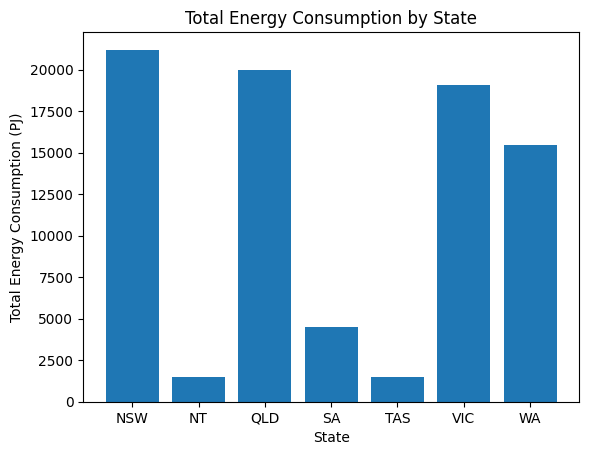

In [ ]:
plt.bar(states, total_consum) #draw a bar chart of lables and sizes
plt.xlabel('State') # x lable name
plt.ylabel('Total Energy Consumption (PJ)') # y lable name
plt.title('Total Energy Consumption by State') # title name
plt.show()# show the chart

**Dicussion**

This bar chart demonstrates the total consumption of energy in 7 different states, NSW has the largest energy consumption, which is above 20000PJ, followed by QLD, around 20000PJ; next is VIC, below 20000PJ. Furthermore, WA is around 15000PJ; SA has around 5000PJ; NT and TAS are both below 2500PJ.

# Compute and visualize the total energy consumption by fuel type.
**By Yuerong Leng 22035974**

In [ ]:
sql = '''
SELECT
    SUM("Coal (PJ)") AS Total_Coal,
    SUM("Oil (PJ)") AS Total_Oil,
    SUM("Gas (PJ)") AS Total_Gas,
    SUM("Renewables (PJ)") AS Total_Renewables
FROM AUS_energy;
'''
# ues source from ChatGPT
# select sum of different four energy as four total consumption
cur.execute(sql) # execute sql
total_energy_by_fuel = cur.fetchone() # fetch data from database
print(total_energy_by_fuel)


(26946.899999999994, 31130.0, 20049.6, 5054.9000000000015)


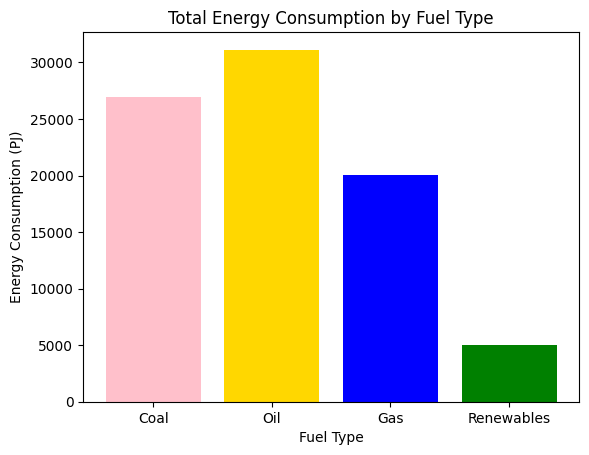

In [ ]:
fuel_types = ['Coal', 'Oil', 'Gas', 'Renewables'] # create lables of bar chart
energy_totals = [total_energy_by_fuel[0], total_energy_by_fuel[1], total_energy_by_fuel[2], total_energy_by_fuel[3]] #create sizes of bar chart

# Creating a bar chart

plt.bar(fuel_types, energy_totals, color=['pink', 'gold', 'blue', 'green']) # draw a bar chart of lables, sizes and colors
plt.title('Total Energy Consumption by Fuel Type') # title name
plt.xlabel('Fuel Type') # x lable name
plt.ylabel('Energy Consumption (PJ)') # y lable name
plt.show() # show the chart

**Dicussion**

This bar chart demonstrates the total energy consumption by fuel type, and according to the bar chart, it shows that the oil energy consumption is the largest, above 30000 PJ, followed by Coal above 25000PJ, next is gas, around 20000PJ, the smallest consumption is the renewables energy is just around 5000PJ.

# Analyse and visualise the total energy consumption for each state, broken down by fuel type.
**By Yaning Wang 21772908**

In [ ]:
# import modules
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# connect the database used
connection = sqlite3.connect('AUS_energy_sqlite3.db')

# create a cursor object to execute SQL queries against the database
cursor = connection.cursor()

In [ ]:
# Execute SQL query to get aggregated data from the table
sql = '''
SELECT State, SUM("Coal (PJ)") AS Coal_Energy_Consumption, SUM("Oil (PJ)") AS Oil_Energy_Consumption, SUM("Gas (PJ)") AS Gas_Energy_Consumption, SUM("Renewables (PJ)") AS Renewables_Energy_Consumption
FROM AUS_energy
GROUP BY State;
'''
# Get the aggregated energy consumption data again and print it
cursor.execute(sql)
results1=cursor.fetchall()
print(results1)

[('NSW', 9076.699999999999, 8902.400000000001, 2071.5, 1148.4), ('NT', 0.0, 628.6999999999999, 862.0000000000001, 11.6), ('QLD', 7259.900000000001, 7338.6, 3747.1, 1633.6), ('SA', 651.6999999999999, 1857.6999999999998, 1549.7000000000003, 448.29999999999995), ('TAS', 143.3, 545.7, 167.8, 618.1999999999999), ('VIC', 8007.499999999999, 6580.5999999999985, 3608.3, 865.1), ('WA', 1807.8000000000002, 5276.3, 8043.200000000001, 329.7)]


In [ ]:
# Extract each column data
states = [result[0] for result in results1]
coal_comsum = [result[1] for result in results1]
oil_comsum = [result[2] for result in results1]
gas_comsum = [result[3] for result in results1]
renewables_comsum = [result[4] for result in results1]
print(states)
print(coal_comsum), (oil_comsum), (gas_comsum), (renewables_comsum)

['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
[9076.699999999999, 0.0, 7259.900000000001, 651.6999999999999, 143.3, 8007.499999999999, 1807.8000000000002]


(None,
 [8902.400000000001,
  628.6999999999999,
  7338.6,
  1857.6999999999998,
  545.7,
  6580.5999999999985,
  5276.3],
 [2071.5,
  862.0000000000001,
  3747.1,
  1549.7000000000003,
  167.8,
  3608.3,
  8043.200000000001],
 [1148.4, 11.6, 1633.6, 448.29999999999995, 618.1999999999999, 865.1, 329.7])

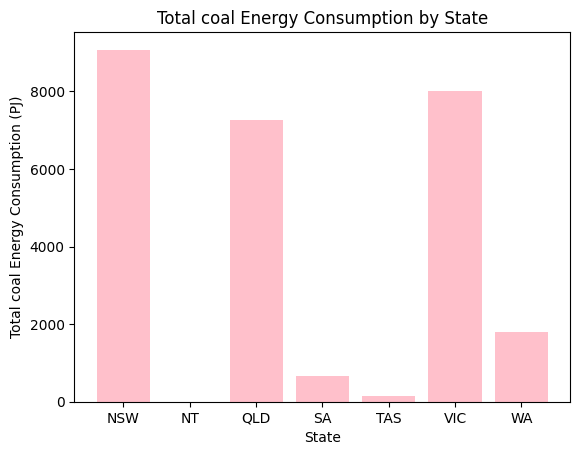

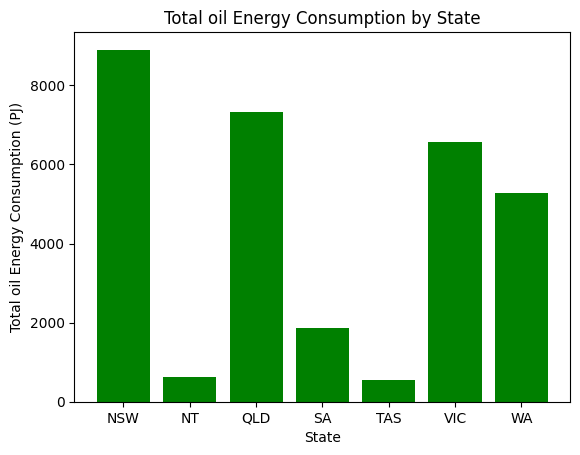

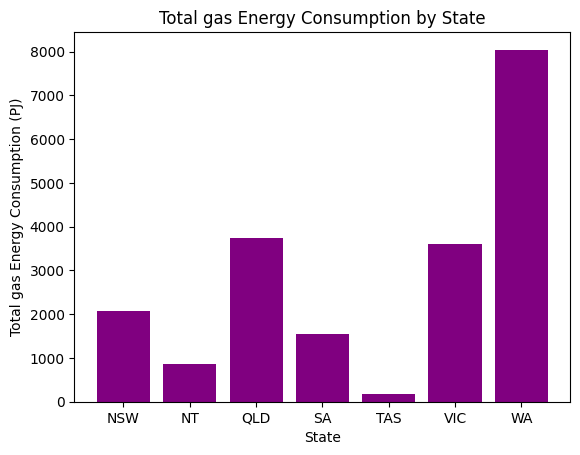

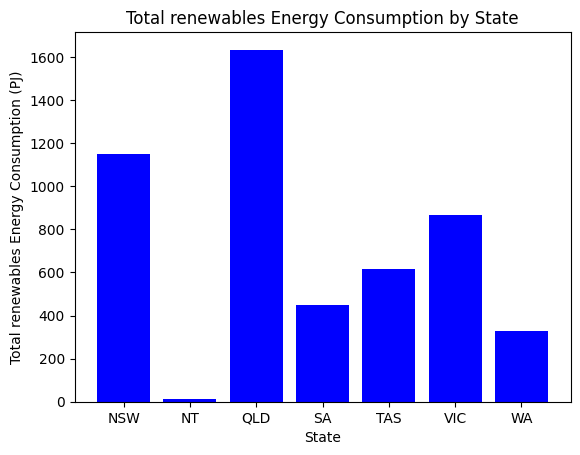

In [ ]:
# Draw a bar chart of total coal consumption
plt.bar(states, coal_comsum,color='pink')
plt.xlabel('State')
plt.ylabel('Total coal Energy Consumption (PJ)')
plt.title('Total coal Energy Consumption by State')
plt.show()

# Draw a bar chart of total oil consumption
plt.bar(states, oil_comsum,color='green')
plt.xlabel('State')
plt.ylabel('Total oil Energy Consumption (PJ)')
plt.title('Total oil Energy Consumption by State')
plt.show()

# Draw a bar chart of total gas consumption
plt.bar(states, gas_comsum,color='purple')
plt.xlabel('State')
plt.ylabel('Total gas Energy Consumption (PJ)')
plt.title('Total gas Energy Consumption by State')
plt.show()

# Draw a bar chart of total renewables consumption
plt.bar(states, renewables_comsum,color='blue')
plt.xlabel('State')
plt.ylabel('Total renewables Energy Consumption (PJ)')
plt.title('Total renewables Energy Consumption by State')
plt.show()

**Discussion**

The bar charts show the total energy consumption by states depending on different energy types (Coal, Oil, Gas, Renewables). All bar charts display that all energy consumption is low in the NT state (maximum less than 1000PJ in all energy consumption and 0PJ of coal energy). Total coal energy consumption is high in NSW, QLD, and VIC states (over 6000PJ) and less than 2000PJ in other states. Total oil energy consumption is high in NSW, QLD, VIC, and WA states (over 4000PJ) and less than 2000PJ in other states. Total gas energy consumption in WA state is highest at about 8000PJ and less than 4000PJ in other states. Total renewable energy consumption is high in NSW and QLD states (over 1000PJ) and less than 1000PJ in other states.

# Analyse and compare the growth rate of the GSP and the consumption of renewable energy for each state.
**By Fang-Ting Hsu 22083753**

In [ ]:
# import modules
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# connect the database used
connection = sqlite3.connect('AUS_energy_sqlite3.db')

# create a cursor object to execute SQL queries against the database
cursor = connection.cursor()

In [ ]:
data = """
SELECT * FROM AUS_energy
"""
cursor.execute(data)
connection.commit()
tab = pd.read_sql_query(data, connection) #creating a variable to store the table to make it easier to call
tab.head(98)

,Year,State,Coal (PJ),Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
0,2008-09,WA,132.9,294.3,474.7,15.6,2240250,244695
1,2008-09,NSW,800.9,587.5,131.6,54.7,7408540,530532
2,2008-09,VIC,695.3,432.9,273.5,33.6,5371934,368579
3,2008-09,QLD,629.2,469.5,187.9,77.4,4328771,284526
4,2008-09,SA,80.2,120.2,134.0,21.2,1608902,100174
...,...,...,...,...,...,...,...,...
93,2021-22,VIC,410.7,410.0,237.5,105.2,6625964,500900
94,2021-22,QLD,485.6,504.7,305.7,143.0,5320496,384508
95,2021-22,SA,25.9,141.6,80.2,48.3,1821200,124252
96,2021-22,TAS,8.8,39.9,7.1,48.1,571013,36701


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             98 non-null     object 
 1   State            98 non-null     object 
 2   Coal (PJ)        98 non-null     object 
 3   Oil (PJ)         98 non-null     float64
 4   Gas (PJ)         98 non-null     float64
 5   Renewables (PJ)  98 non-null     float64
 6   Population       98 non-null     int64  
 7   GSP ($ million)  98 non-null     int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 6.2+ KB


In [ ]:
df.describe()

,Oil (PJ),Gas (PJ),Renewables (PJ),Population,GSP ($ million)
count,98.000000,98.000000,98.000000,9.800000e+01,98.000000
mean,317.653061,204.587755,51.580612,3.424330e+06,266337.000000
std,229.318224,179.205651,38.383143,2.769970e+06,209376.485897
min,33.400000,6.600000,0.400000,2.260270e+05,19469.000000
25%,54.350000,81.675000,24.025000,5.502752e+05,33440.000000
50%,379.100000,144.700000,42.500000,2.548325e+06,301927.000000
75%,507.675000,263.600000,72.600000,5.622772e+06,390060.250000
max,687.400000,692.600000,143.000000,8.622575e+06,706003.000000


In [ ]:
# Connect to the SQLite database
conn = sqlite3.connect('AUS_energy_sqlite3.db')

# Load data into a Pandas DataFrame
query = '''
SELECT Year, State, "Renewables (PJ)", "GSP ($ million)"
FROM AUS_energy
'''
df = pd.read_sql_query(query, conn)

# Calculate GSP growth rate for each state
df['GSP_growth_rate'] = df.groupby('State')['GSP ($ million)'].pct_change() * 100

# Drop rows with NaN values in 'gsp_growth_rate'
df = df.dropna(subset=['GSP_growth_rate'])

**Gen AI prompt:**\
How to compare the total renewables consumption and  GSP growth rate by state

**Gen AI response:**

In [ ]:
# Aggregate data to get the total renewables consumption and average GSP growth rate by state
state_data = df.groupby('State').agg({
    'GSP_growth_rate': 'mean',
    'Renewables (PJ)': 'sum'
}).reset_index()

**Effectives:** Need to change the date name 'state' to 'State' and 'renewables' to 'Renewable (PJ)' to complete the dataset.\
**Modification Needed:** 'state' to 'State' and 'renewables' to 'Renewable (PJ)'

**Gen AI prompt:**\
 Which kind of visual drawing are best to correlation between two variables in different state

**Gen AI response:**

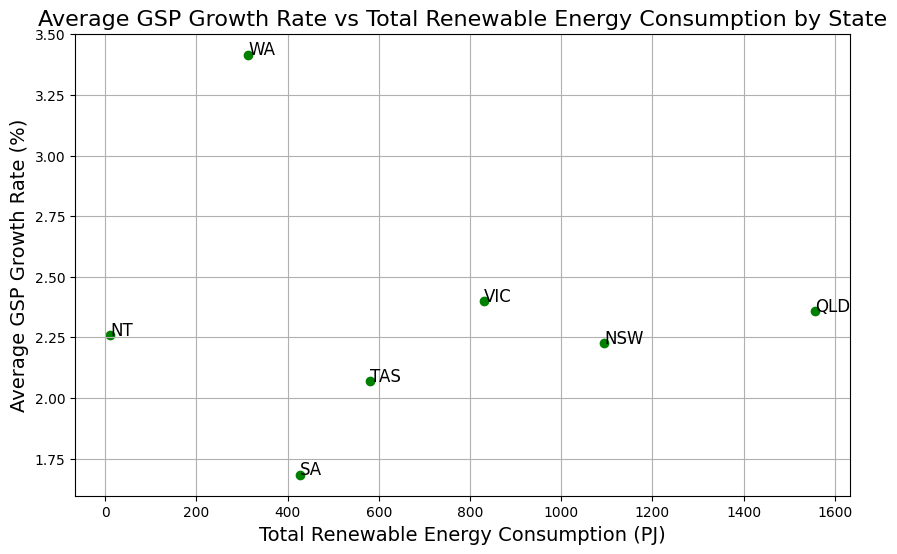

In [ ]:
# Visualization by scatter
plt.figure(figsize=(10, 6))
plt.scatter(state_data['Renewables (PJ)'], state_data['GSP_growth_rate'], color='green')

# Defined the name of titles and labels
plt.title('Average GSP Growth Rate vs Total Renewable Energy Consumption by State', fontsize=16)
plt.xlabel('Total Renewable Energy Consumption (PJ)', fontsize=14)
plt.ylabel('Average GSP Growth Rate (%)', fontsize=14)

# Defined each point with the state name
for i, row in state_data.iterrows():
    plt.text(row['Renewables (PJ)'], row['GSP_growth_rate'], row['State'], fontsize=12,)

plt.grid(True)
plt.show()

# Close the database connection
conn.close()

**Effectives:**
Need to change the date name 'state' to 'State' and 'renewables' to 'Renewable (PJ)' to complete the dataset. \
**Modification Needed:**
'state' to 'State' and
'renewables' to 'Renewable (PJ)'

**Disscussion**\
The scatter plot analysis shows the positive and negative relationship between renewable energy and economic growth in each state. The total renewable energy consumption in Western Australia is below the median, and the GSP growth rate is nearly 3.5%, showing a positive correlation between renewable energy consumption and economic growth. Queensland's total renewable energy consumption is as high as nearly 1600 (PJ), but its GSP only reaches the median. Although South Australia's total renewable energy consumption is below the median, its GSP growth rate is less than 1.75%. These results may also affected by population, policy implementation or other economic issues. Analyze the scatter to develop strategies to help ensure all states maximise the financial benefits of renewable energy and promote sustainable economic growth.